In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


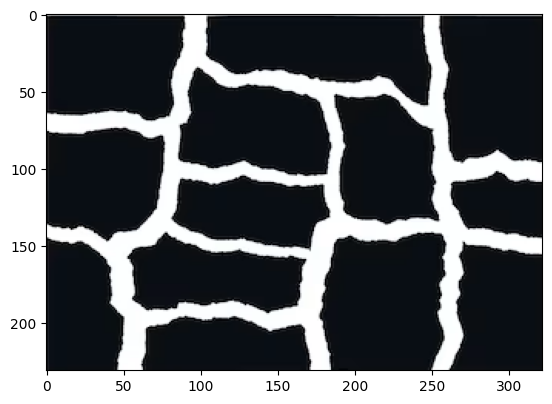

In [16]:
img = cv2.imread(r"Z:\Internship\Tasks\Edge Detection\image\image1.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img)
plt.show()


In [17]:
thresh=cv2.threshold(gray, 240, 245, cv2.THRESH_BINARY_INV)[1]


In [18]:
# edges = cv2.Canny(thresh, 50, 150)

In [19]:
# plt.imshow(edges,cmap='gray')
# plt.title('Detected contours')
# plt.show() 

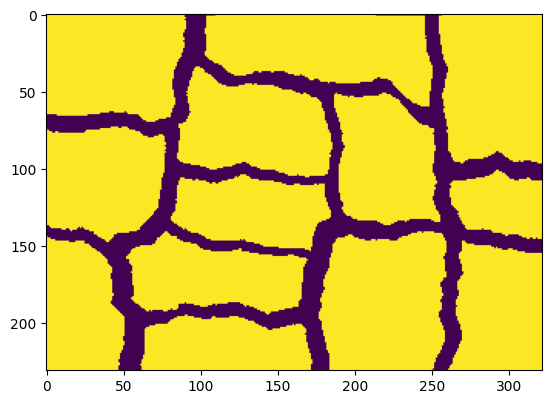

In [20]:
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

img1=img.copy()

mask = np.zeros_like(thresh)
cv2.drawContours(mask, contours, -1, (255,255,255), -1)

plt.imshow(mask)
plt.show()


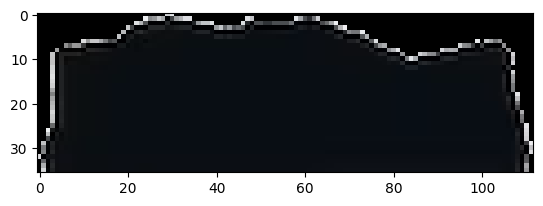

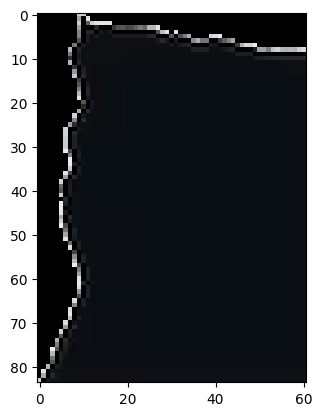

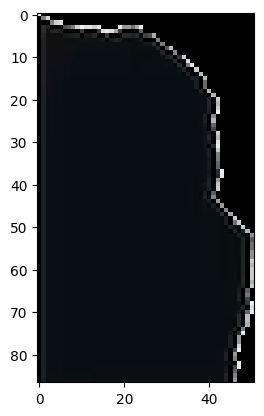

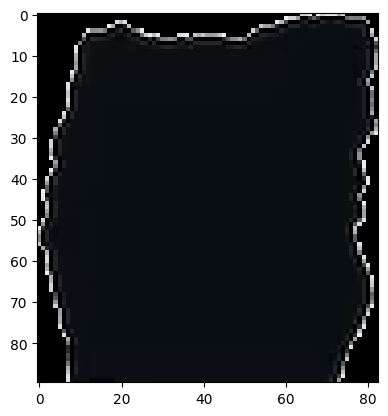

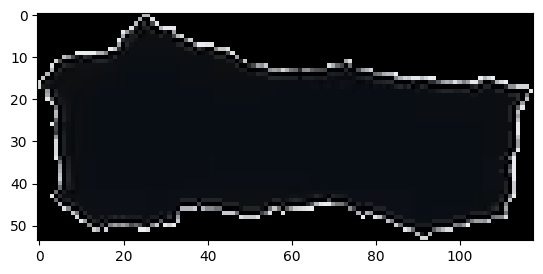

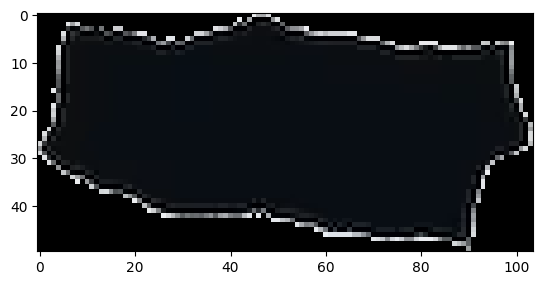

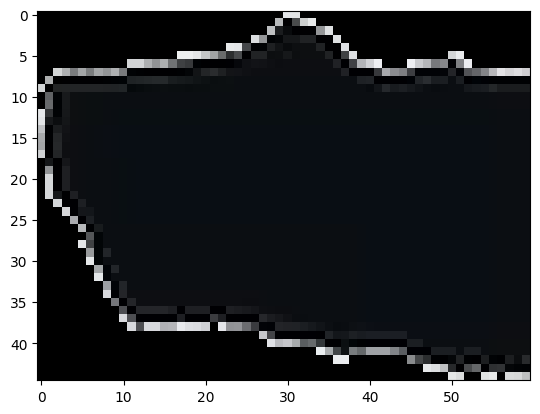

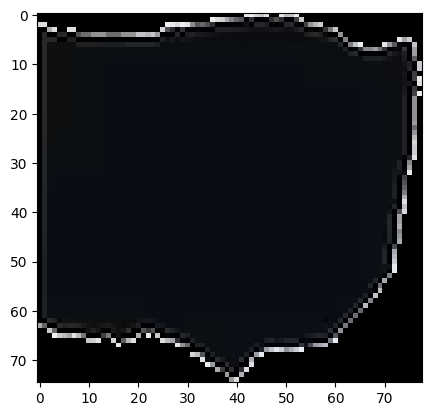

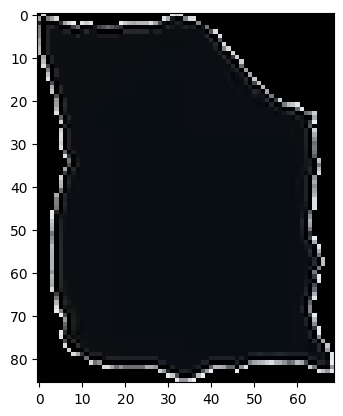

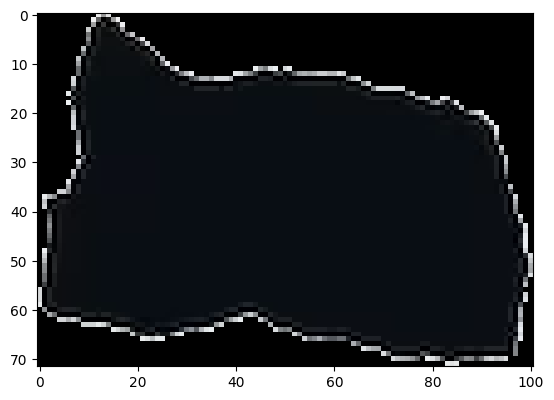

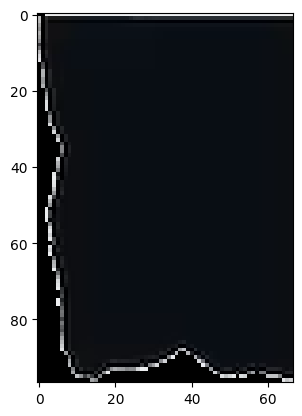

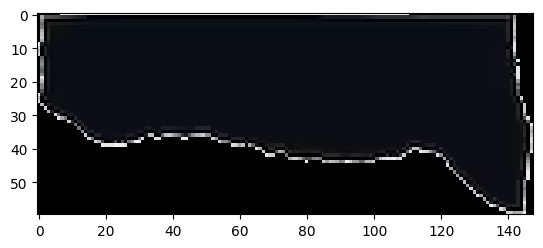

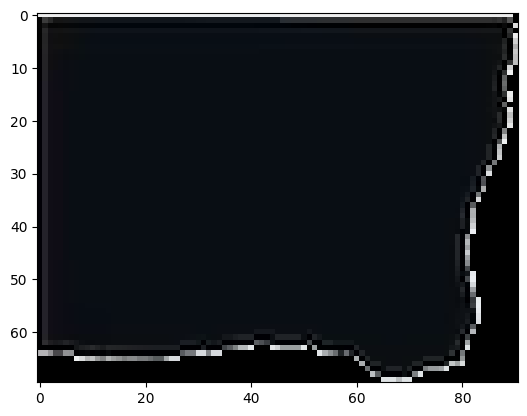

In [21]:
con=[]
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
for i, cnt in enumerate(contours):
    if cv2.contourArea(cnt)<100:
        continue
    mask=np.zeros_like(thresh)
    cv2.drawContours(mask, [cnt],-1,255,thickness=cv2.FILLED)

    isolated_piece=cv2.bitwise_and(img,img,mask=mask)
    x,y,w,h = cv2.boundingRect(cnt)
    cropped_piece=isolated_piece[y:y+h, x:x+w]

    con.append(cropped_piece)

    plt.imshow(cropped_piece)
    plt.show()



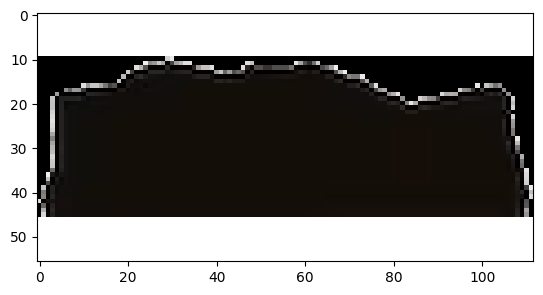

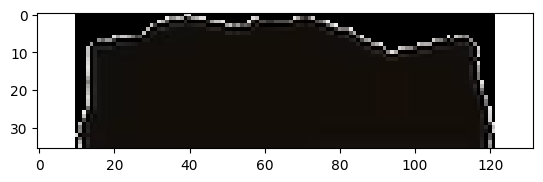

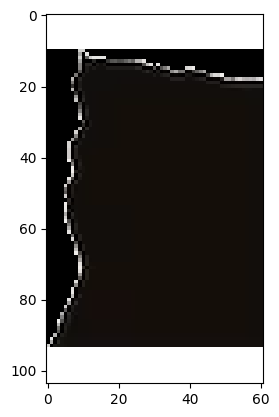

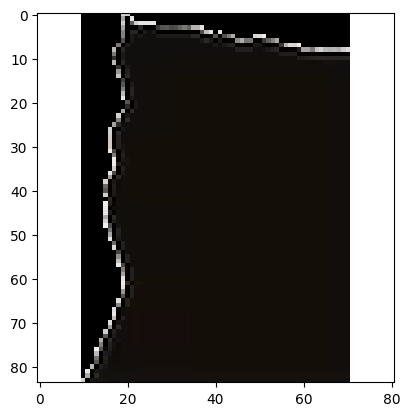

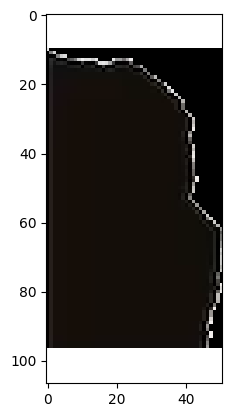

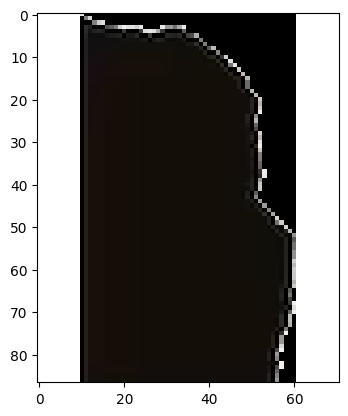

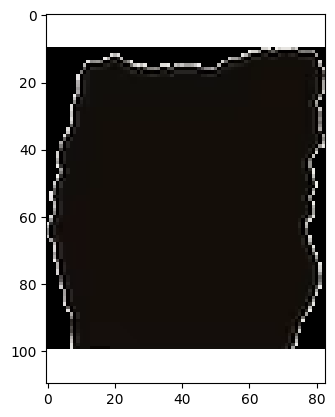

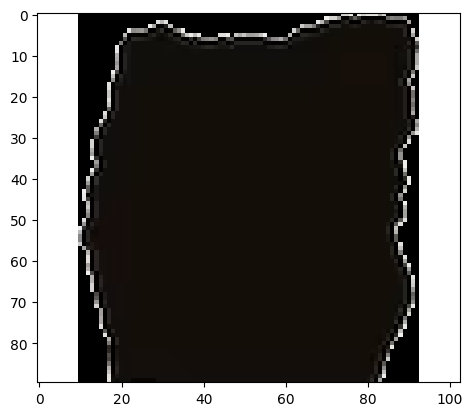

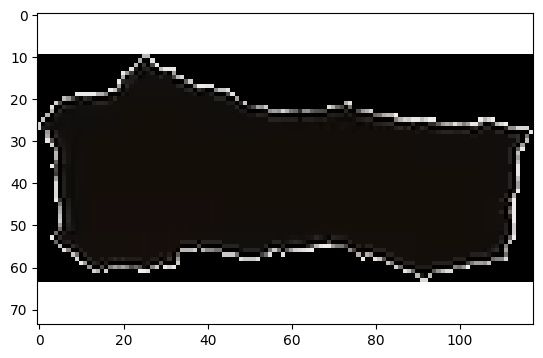

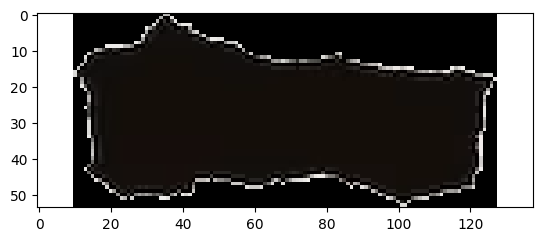

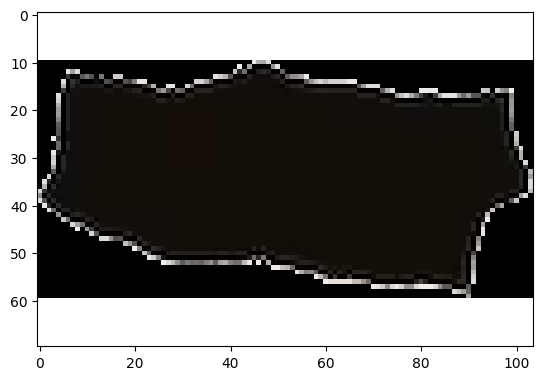

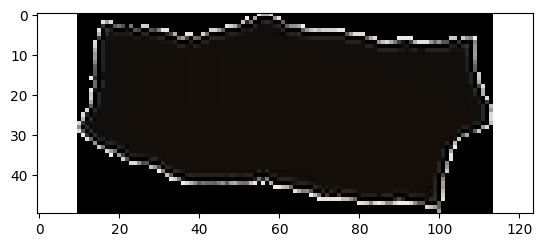

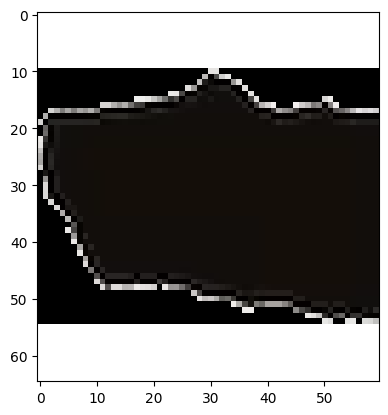

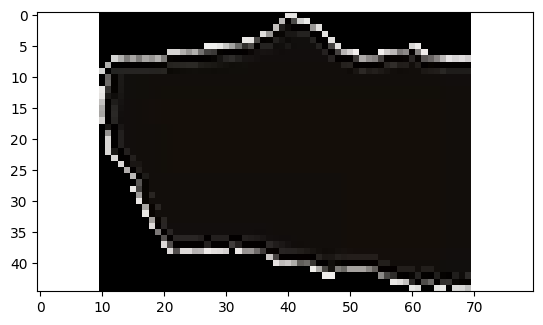

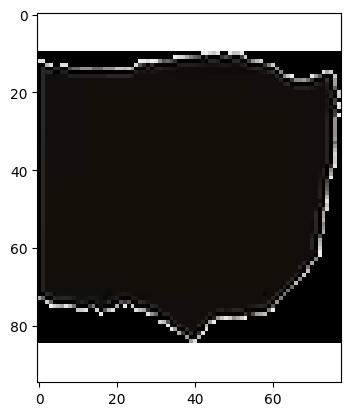

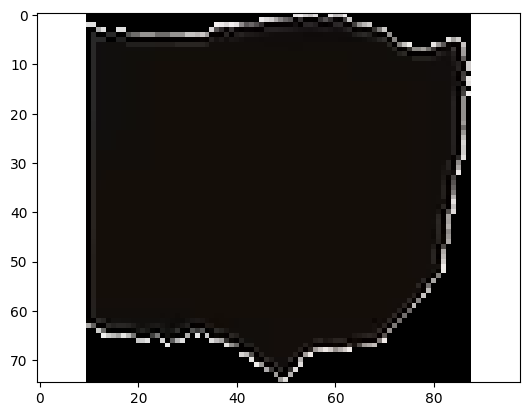

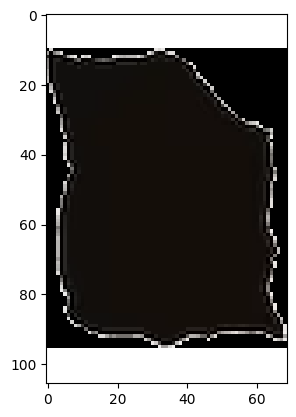

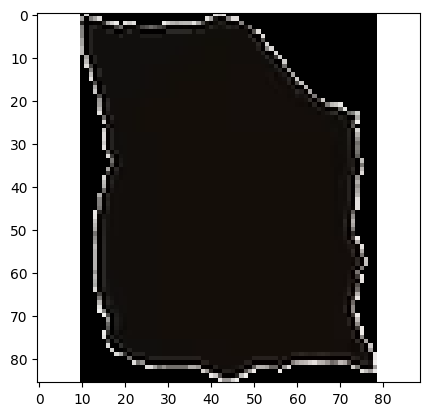

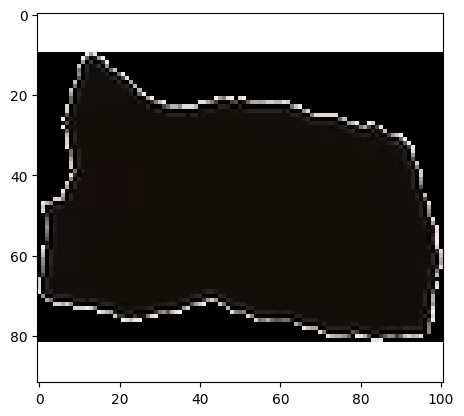

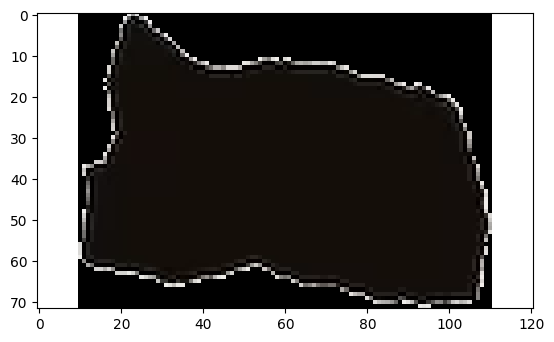

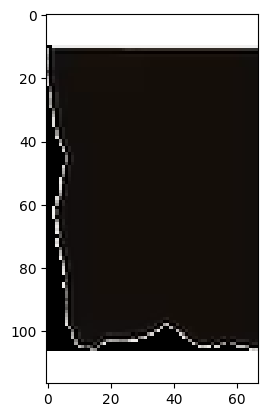

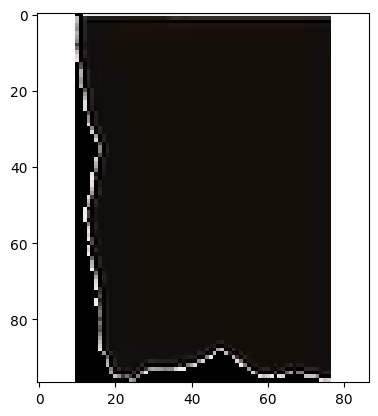

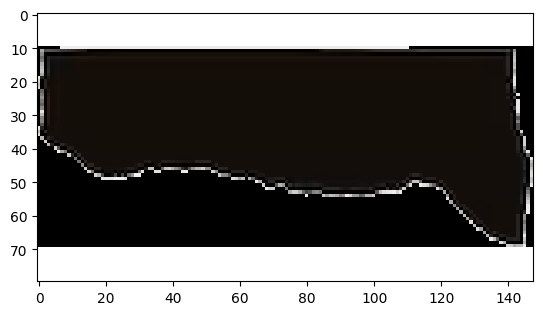

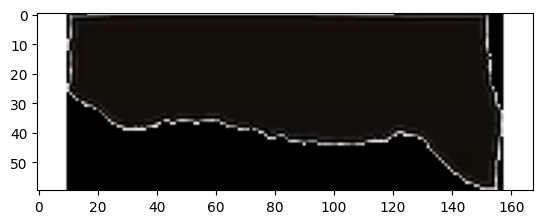

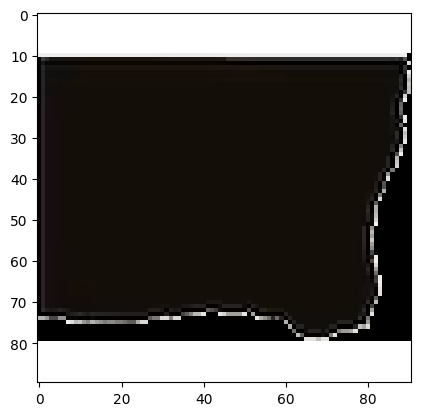

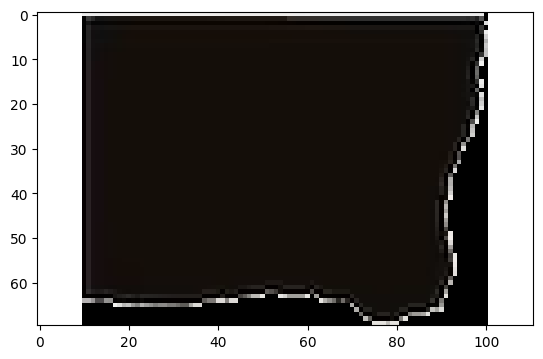

In [22]:
for i in con:
    padded_piece = cv2.copyMakeBorder(i, 10, 10, 0, 0, borderType=cv2.BORDER_CONSTANT, value=[255, 255, 255])
    padded_piece1 = cv2.copyMakeBorder(i, 0, 0, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[255, 255, 255])
    
    plt.imshow(cv2.cvtColor(padded_piece, cv2.COLOR_BGR2RGB))
    plt.show()
    
    plt.imshow(cv2.cvtColor(padded_piece1, cv2.COLOR_BGR2RGB))
    plt.show()

111 25


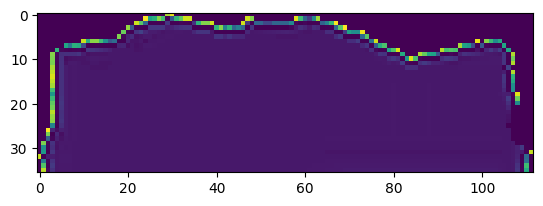

60 7


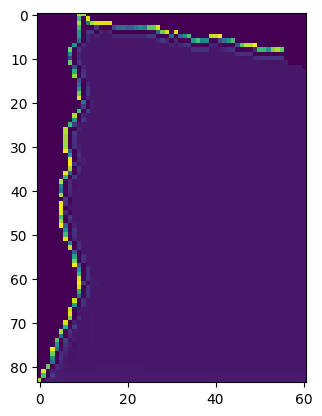

50 50


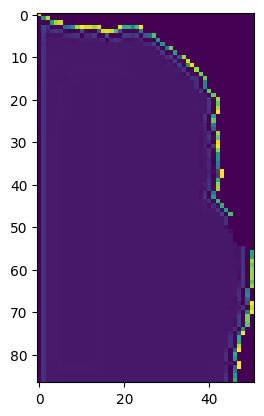

82 3


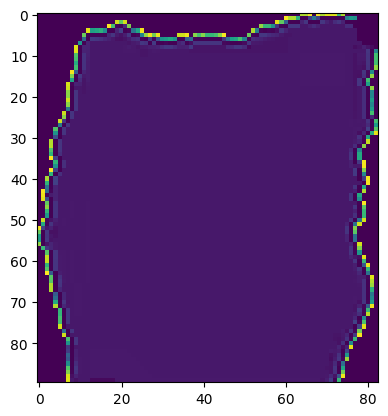

117 17


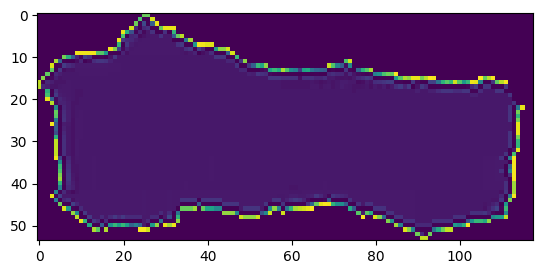

103 20


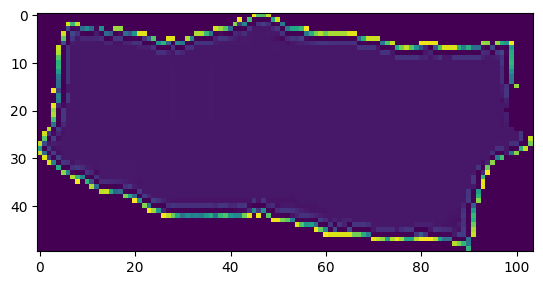

59 6


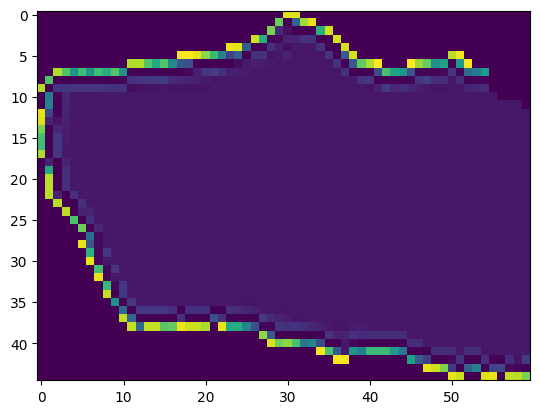

77 5


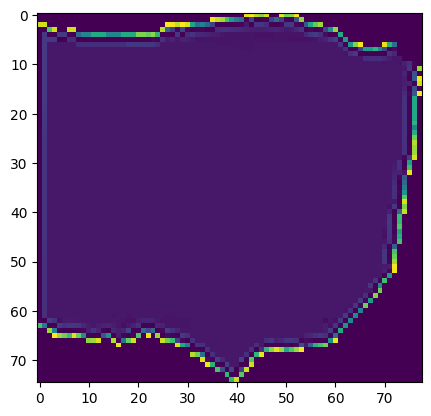

68 76


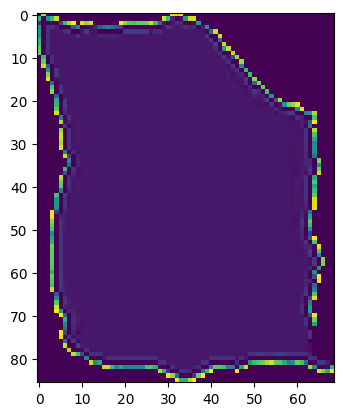

100 43


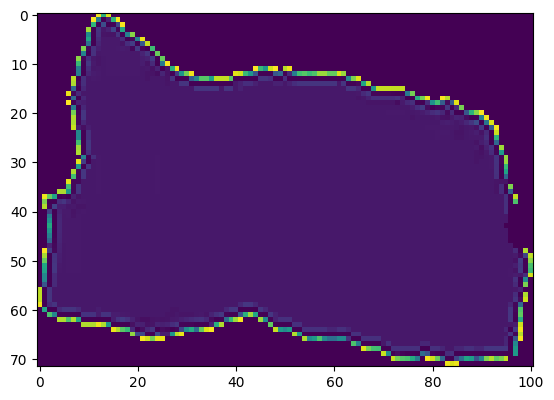

66 1


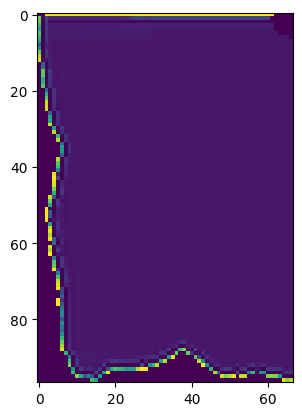

147 30


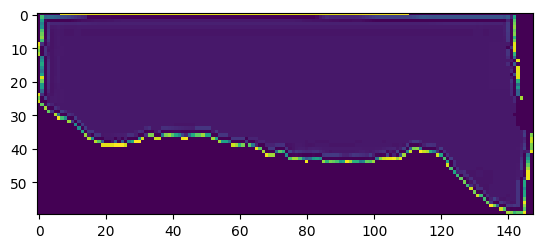

90 1


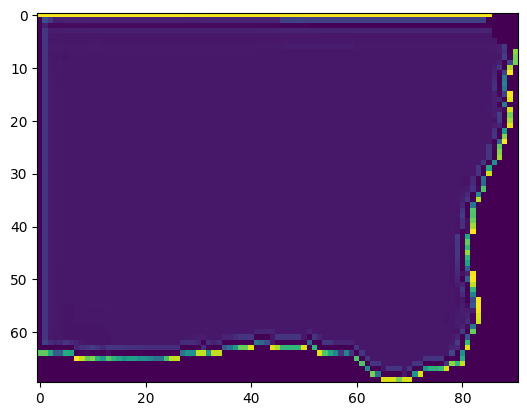

In [23]:
for i in con:
 gray_padded = cv2.cvtColor(i, cv2.COLOR_BGR2GRAY)
 edges = cv2.Canny(gray_padded, 50, 150)
 y,x=np.where(edges==255)
 highest =np.argmin(x)
 highest =np.argmax(x)

 x1=x[highest]
 y1=y[highest]
 print(x1,y1)

 cv2.circle(gray_padded,(x1,y1), 5,(0,0,255),-1)

 plt.imshow(gray_padded)
 plt.show() 


23 0


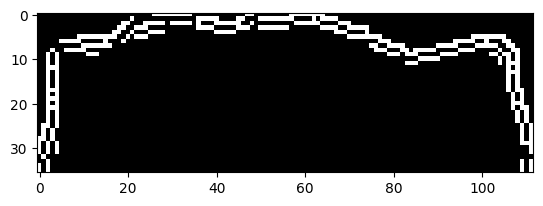

In [24]:
gray_padded = cv2.cvtColor(con[0], cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray_padded, 50, 150)
y,x=np.where(edges==255)
highest =np.min(y)
x1=x[highest]
y1=y[highest]
print(x1,y1)

cv2.circle(edges,(x1,y1), 2,(0,0,255),-1)

plt.imshow(edges,cmap='gray')
plt.show()


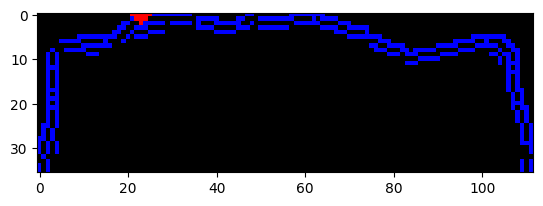

In [25]:
colored_edges = np.zeros((edges.shape[0], edges.shape[1], 3), dtype=np.uint8)

colored_edges[edges == 255] = [255, 0, 0] 

cv2.circle(colored_edges, (x1, y1), 2, (0, 0, 255), -1) 

plt.imshow(cv2.cvtColor(colored_edges, cv2.COLOR_BGR2RGB))
plt.show()

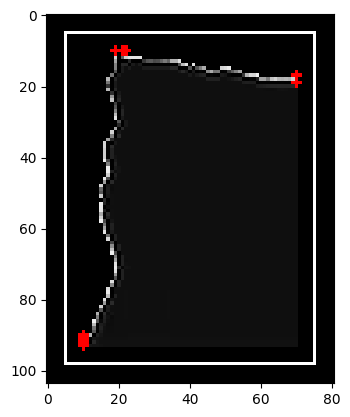

In [26]:
gray_padded = cv2.cvtColor(con[1], cv2.COLOR_BGR2GRAY) if len(con[1].shape) == 3 else con[1].copy()

edges = cv2.Canny(gray_padded, 50, 150)
y, x = np.where(edges == 255)

padding_color = [0, 0, 0] 
output_img = cv2.cvtColor(gray_padded, cv2.COLOR_GRAY2BGR)
output_img = cv2.copyMakeBorder(output_img, 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=padding_color)

x = x + 10
y = y + 10

bottom = np.max(y)  
right = np.max(x)   
top = np.min(y) 
left = np.min(x)   

y1 = x[y == bottom]
for peak_x in y1:
    cv2.circle(output_img, (peak_x, bottom), 1, (0, 0, 255), -1)

y2 = y[x == right] 
for peak_y in y2:
    cv2.circle(output_img, (right, peak_y), 1, (0, 0, 255), -1) 

y3 = x[y == top] 
for peak_x in y3:
    cv2.circle(output_img, (peak_x, top), 1, (0, 0, 255), -1)

y4 = y[x == left] 
for peak_y in y4:
    cv2.circle(output_img, (left, peak_y), 1, (0, 0, 255), -1)

g1 = 5
b1 = (left - g1, top - g1)
b2 = (right + g1, bottom + g1)
cv2.rectangle(output_img, b1, b2, (255, 255, 255), 1)

plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.show()

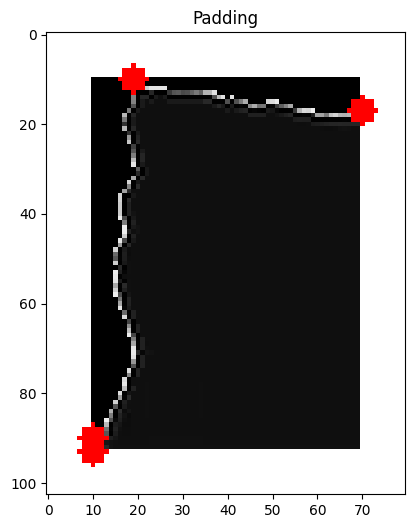

In [27]:
mask = gray_padded < 240 
y, x = np.where(mask & (edges == 255)) 

indices = {
    "min_x": np.argmin(x),
    "max_x": np.argmax(x),
    "min_y": np.argmin(y),
    "max_y": np.argmax(y)
}

pts = [(x[idx], y[idx]) for idx in indices.values()]

xmin, ymin = np.min(pts, axis=0)
xmax, ymax = np.max(pts, axis=0)

cropped_obj = gray_padded[ymin:ymax, xmin:xmax]

padding = 10  
padded_final = cv2.copyMakeBorder(
    cropped_obj, 
    padding, padding, padding, padding, 
    borderType=cv2.BORDER_CONSTANT, 
    value=[255, 255, 255]
)
output_img = cv2.cvtColor(padded_final, cv2.COLOR_GRAY2BGR)

for pt in pts:

    new_x = (pt[0] - xmin) + padding
    new_y = (pt[1] - ymin) + padding
    cv2.circle(output_img, (new_x, new_y), 3, (0, 0, 255), -1)

plt.figure(figsize=(8, 6))
plt.title("Padding")
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.show()